In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "torch"

import math
import numpy as np
import seaborn as sns
import pandas as pd
import keras
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import truncnorm
from numba import njit

import bayesflow as bf

import DDMChelpers

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


In [150]:
@njit
def ddmc_trial(t0, muc, b, A1, A2, tau1, tau2, sigma = 4.0, dt = 1.0, max_time = 7000): 

    dX = 0#np.random.beta(3, 3) * (2 * b) - b    # initial position
    const = sigma * np.sqrt(dt)
    t = dt

    # Loop through process and check boundary conditions
    while (b > dX > -b) and t <= max_time:
        
        noise = np.random.randn()
        noise = 0
        # with a1 = a2 = 2
        mu_a1 = A1 / tau1 * np.exp(1 - t / tau1) * (1 - t / tau1)
        mu_a2 = A2 / tau2 * np.exp(1 - t / tau2) * (1 - t / tau2)
        mu_t = mu_a1 + mu_a2 + muc
        
        dX += mu_t * dt + const * noise

        t += dt

    # Get decision
    rt = t + t0
    if dX >= b:     # correct
        c = 1.0
    elif dX <= -b:  # incorrect
        c = 0.0
    else:           # no decision within max_time
        c = -1.0
        rt = -1.0

    # Convert to seconds
    rt = rt / 1000

    return c, rt

print(ddmc_trial(muc=0.5, A1=-60, A2=-30, tau1=10, tau2=170, b=50, t0=300))

def simulate_ddmc(t0, muc, b, A1, A2, tau1, tau2, n_subjects=1, n_trials=1):
    if isinstance(muc, (float, int)):
        t0 = np.ones((n_subjects, )) * t0
        muc = np.ones((n_subjects, )) * muc
        b = np.ones((n_subjects, )) * b
        A1 = np.ones((n_subjects, )) * A1
        A2 = np.ones((n_subjects, )) * A2
        tau1 = np.ones((n_subjects, )) * tau1
        tau2 = np.ones((n_subjects, )) * tau2

    quarter = int(np.ceil(n_trials / 4)) 
    conditions = np.repeat(np.arange(4), quarter)[:n_trials]

    data = np.zeros((n_subjects, n_trials, 2))

    for i in range(n_subjects):
        for j in range(n_trials):
            auto1 = 1 if (conditions[j] == 0 or conditions[j] == 1) else -1 # CC, CI
            auto2 = 1 if (conditions[j] == 0 or conditions[j] == 2) else -1 # CC, IC
            data[i, j] = ddmc_trial(
                t0[i], muc[i], b[i], auto1*A1[i], auto2*A2[i], tau1[i], tau2[i]
            )

    if n_subjects == 1 and n_trials == 1:
        data = data[0, 0]
    elif n_subjects == 1:
        data = data[0]
    elif n_trials == 1:
        data = data[:, 0]
    
    return dict(sim_data=data, conditions=conditions)
print(simulate_ddmc(300, 0.5, 50, 30, 30, 30, 170, n_subjects=1, n_trials=1))



(0.0, 0.309)
{'sim_data': array([1.   , 0.325]), 'conditions': array([0])}


In [ ]:
global_prior = {
    'mu_t0'     : (300.0, 30.0), 
    'mu_muc'    : (0.5, 0.1),
    'mu_b'      : (55, 15),
    'mu_A1'     : (20, 8), 
    'mu_A2'     : (20, 8), 
    'mu_tau1' : ([30, 180], 15),
    'mu_tau2' : ([30, 180], 15),
#    'mu_tau1' : (30, 8),
#    'mu_tau2' : (180, 8),

    'log_sigma_t0'  : (5.5, 0.5),
    'log_sigma_muc' : (-0.7, 0.5),
    'log_sigma_b'   : (4.0, 0.5),
    'log_sigma_A1'  : (2.0, 0.5),
    'log_sigma_A2'  : (2.0, 0.5),
    'log_sigma_tau1': (2.5, 0.5),
    'log_sigma_tau2': (2.5, 0.5),
}


def sample_hierarchical_priors(rng=None, n_subjects = 1):
    if rng == None: 
        rng = np.random.default_rng()

    ax = 0
    bx = np.inf

    # Group level
    mu_t0   = truncnorm.rvs(
        (ax - global_prior['mu_t0'][0]) / global_prior['mu_t0'][1], 
        (bx - global_prior['mu_t0'][0]) / global_prior['mu_t0'][1], 
        global_prior['mu_t0'][0], global_prior['mu_t0'][1], random_state = rng
    )
    mu_muc  = truncnorm.rvs(
        (ax - global_prior['mu_muc'][0]) / global_prior['mu_muc'][1], 
        (bx - global_prior['mu_muc'][0]) / global_prior['mu_muc'][1], 
        global_prior['mu_muc'][0],  global_prior['mu_muc'][1], random_state = rng
    )
    mu_b    = truncnorm.rvs(
        (ax - global_prior['mu_b'][0]) /  global_prior['mu_b'][1], 
        (bx - global_prior['mu_b'][0]) /  global_prior['mu_b'][1], 
        global_prior['mu_b'][0],  global_prior['mu_b'][1], random_state = rng
    )
    mu_A1   = truncnorm.rvs(
        (ax - global_prior['mu_A1'][0]) / global_prior['mu_A1'][1], 
        (bx - global_prior['mu_A1'][0]) / global_prior['mu_A1'][1], 
        global_prior['mu_A1'][0], global_prior['mu_A1'][1], random_state = rng
    )
    mu_A2   = truncnorm.rvs(
        (ax - global_prior['mu_A2'][0]) / global_prior['mu_A2'][1], 
        (bx - global_prior['mu_A2'][0]) / global_prior['mu_A2'][1], 
        global_prior['mu_A2'][0], global_prior['mu_A2'][1], random_state = rng
    )
    
#    mu_tau1 = rng.normal(global_prior['mu_tau1'][0], global_prior['mu_tau1'][1])
#    mu_tau2 = rng.normal(global_prior['mu_tau2'][0], global_prior['mu_tau2'][1])
    # Mixture distribution for tau1, tau2
    c1 = rng.binomial(1, 0.5)
    c2 = rng.binomial(1, 0.5)
    if c1 == 0: 
        mu_tau1 = truncnorm.rvs(
            (ax - global_prior['mu_tau1'][0][0]) / global_prior['mu_tau1'][1], 
            (bx - global_prior['mu_tau1'][0][0]) / global_prior['mu_tau1'][1], 
            global_prior['mu_tau1'][0][0], global_prior['mu_tau1'][1], 
            random_state = rng
        )
#        rng.normal(global_prior['mu_tau1'][0][0], global_prior['mu_tau1'][1])
    else: 
        mu_tau1 = truncnorm.rvs(
            (ax - global_prior['mu_tau1'][0][1]) / global_prior['mu_tau1'][1], 
            (bx - global_prior['mu_tau1'][0][1]) / global_prior['mu_tau1'][1], 
            global_prior['mu_tau1'][0][1], global_prior['mu_tau1'][1], 
            random_state = rng
        )
#        mu_tau1 = rng.normal(global_prior['mu_tau1'][0][1], global_prior['mu_tau1'][1])
       
    if c2 == 0: 
        mu_tau2 = truncnorm.rvs(
            (ax - global_prior['mu_tau2'][0][0]) / global_prior['mu_tau2'][1], 
            (bx - global_prior['mu_tau2'][0][0]) / global_prior['mu_tau2'][1], 
            global_prior['mu_tau2'][0][0], global_prior['mu_tau2'][1], 
            random_state = rng
        )
#        mu_tau2 = rng.normal(global_prior['mu_tau2'][0][0], global_prior['mu_tau2'][1])
    else: 
        mu_tau2 = truncnorm.rvs(
            (ax - global_prior['mu_tau2'][0][1]) / global_prior['mu_tau2'][1], 
            (bx - global_prior['mu_tau2'][0][1]) / global_prior['mu_tau2'][1], 
            global_prior['mu_tau2'][0][1], global_prior['mu_tau2'][1], 
            random_state = rng
        )
#        mu_tau2 = rng.normal(global_prior['mu_tau2'][0][1], global_prior['mu_tau2'][1])

    log_sigma_t0 = rng.normal(*global_prior['log_sigma_t0'])
    log_sigma_b = rng.normal(*global_prior['log_sigma_b'])
    log_sigma_muc = rng.normal(*global_prior['log_sigma_muc'])
    log_sigma_A1 = rng.normal(*global_prior['log_sigma_A1'])
    log_sigma_A2 = rng.normal(*global_prior['log_sigma_A2'])
    log_sigma_tau1 = rng.normal(*global_prior['log_sigma_tau1'])
    log_sigma_tau2 = rng.normal(*global_prior['log_sigma_tau2'])

    # Subject level
    t0 = truncnorm.rvs(
        (ax - mu_t0) / np.exp(log_sigma_t0), (bx - mu_t0) / np.exp(log_sigma_t0), 
        mu_t0, np.exp(log_sigma_t0), size=n_subjects, random_state=rng
    )
    muc = truncnorm.rvs(
        (ax - mu_muc) / np.exp(log_sigma_muc), (bx - mu_muc) / np.exp(log_sigma_muc), 
        mu_muc, np.exp(log_sigma_muc), size=n_subjects, random_state = rng
    )
    b = truncnorm.rvs(
        (ax - mu_b) / np.exp(log_sigma_b), (bx - mu_b) / np.exp(log_sigma_b), 
        mu_b, np.exp(log_sigma_b), size=n_subjects, random_state = rng
    )
    A1 = truncnorm.rvs(
        (ax - mu_A1) / np.exp(log_sigma_A1), (bx - mu_A1) / np.exp(log_sigma_A1), 
        mu_A1, np.exp(log_sigma_A1), size=n_subjects, random_state = rng
    )
    A2 = truncnorm.rvs(
        (ax - mu_A2) / np.exp(log_sigma_A2), (bx - mu_A2) / np.exp(log_sigma_A2), 
        mu_A2, np.exp(log_sigma_A2), size=n_subjects, random_state = rng
    )
#    tau1 = rng.normal(mu_tau1, np.exp(log_sigma_tau1), size=n_subjects)
#    tau2 = rng.normal(mu_tau2, np.exp(log_sigma_tau2), size=n_subjects)
    tau1 = truncnorm.rvs(
        (ax - mu_tau1) / np.exp(log_sigma_tau1), 
        (bx - mu_tau1) / np.exp(log_sigma_tau1), 
        mu_tau2, np.exp(log_sigma_tau2), size=n_subjects, random_state = rng
    )
    tau2 = truncnorm.rvs(
        (ax - mu_tau2) / np.exp(log_sigma_tau2), 
        (bx - mu_tau2) / np.exp(log_sigma_tau2), 
        mu_tau2, np.exp(log_sigma_tau2), size=n_subjects, random_state = rng
    )

    return {
        # group 
        'mu_t0': mu_t0, 'mu_muc': mu_muc, 'mu_b': mu_b, 'mu_A1': mu_A1, 
        'mu_A2': mu_A2, 'mu_tau1': mu_tau1, 'mu_tau2' : mu_tau2, 
        'log_sigma_t0': log_sigma_t0, 'log_sigma_muc': log_sigma_muc, 
        'log_sigma_b': log_sigma_b, 'log_sigma_A1': log_sigma_A1, 
        'log_sigma_A2'  : log_sigma_A2, 'log_sigma_tau1': log_sigma_tau1, 
        'log_sigma_tau2': log_sigma_tau2, 

        # subject
        't0': t0, 'muc': muc, 'b': b, 'A1': A1, 'A2': A2, 'tau1': tau1, 
        'tau2': tau2
        }

print(sample_hierarchical_priors())

{'mu_t0': np.float64(318.1668347687843), 'mu_muc': np.float64(0.6521465383186426), 'mu_b': np.float64(82.35604135969021), 'mu_A1': np.float64(12.02380773469045), 'mu_A2': np.float64(31.005260983218687), 'mu_tau1': np.float64(3.506775880176619), 'mu_tau2': np.float64(136.0027621653527), 'log_sigma_t0': 5.201741031031148, 'log_sigma_muc': -1.1366185039302326, 'log_sigma_b': 3.7930882394917798, 'log_sigma_A1': 1.8825207285139238, 'log_sigma_A2': 3.3227037482767425, 'log_sigma_tau1': 2.122519866667199, 'log_sigma_tau2': 3.1066713375396686, 't0': array([447.56062361]), 'muc': array([0.20539998]), 'b': array([11.26318195]), 'A1': array([9.92802376]), 'A2': array([16.4271431]), 'tau1': array([5.52407296]), 'tau2': array([102.55581941])}


In [157]:
def score_log_norm(x, m, s):
    return -(x-m) / s**2

def score_log_mixture(x, m1, s1, m2, s2):
    n1 = np.exp(-0.5 * ((x - m1) / s1) ** 2) / (np.sqrt(2*np.pi) * s1)
    n2 = np.exp(-0.5 * ((x - m2) / s2) ** 2) / (np.sqrt(2*np.pi) * s2)

    p = 0.5 * n1 + 0.5 * n2

    return (
        0.5 * n1 * (-(x - m1) / s1**2)
        + 0.5 * n2 * (-(x - m2) / s2**2)
    ) / p

    
def prior_global_score(x: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    mu_t0   = x["mu_t0"]
    mu_muc  = x["mu_muc"]
    mu_b    = x["mu_b"]
    mu_A1   = x["mu_A1"]
    mu_A2   = x["mu_A2"]
    mu_tau1 = x["mu_tau1"]
    mu_tau2 = x["mu_tau2"]
    log_sigma_t0    = x["log_sigma_t0"]
    log_sigma_muc   = x["log_sigma_muc"]
    log_sigma_b     = x["log_sigma_b"]
    log_sigma_A1    = x["log_sigma_A1"]
    log_sigma_A2    = x["log_sigma_A2"]
    log_sigma_tau1  = x["log_sigma_tau1"]
    log_sigma_tau2  = x["log_sigma_tau2"]

    parts = {
        "mu_t0": score_log_norm(
            mu_t0, m=global_prior["mu_t0"][0], s=global_prior["mu_t0"][1]
        ),
        "mu_muc": score_log_norm(
            mu_muc, m=global_prior["mu_muc"][0], s=global_prior["mu_muc"][1]
        ),
        "mu_b": score_log_norm(
            mu_b, m=global_prior["mu_b"][0], s=global_prior["mu_b"][1]
        ),
        "mu_A1": score_log_norm(
            mu_A1, m=global_prior["mu_A1"][0], s=global_prior["mu_A1"][1]
        ),
        "mu_A2": score_log_norm(
            mu_A2, m=global_prior["mu_A2"][0], s=global_prior["mu_A2"][1]
        ),
#        "mu_tau1": score_log_norm(mu_tau1, m=global_prior["mu_tau1"][0], s=global_prior["mu_tau1"][1]),
#        "mu_tau2": score_log_norm(mu_tau2, m=global_prior["mu_tau2"][0], s=global_prior["mu_tau2"][1]),
        "mu_tau1": score_log_mixture(
            mu_tau1, 
            m1=global_prior["mu_tau1"][0][0],m2=global_prior["mu_tau1"][0][1], 
            s1=global_prior["mu_tau1"][1], s2=global_prior["mu_tau1"][1]
        ),
        "mu_tau2": score_log_mixture(
            mu_tau2, 
            m1=global_prior["mu_tau2"][0][0],m2=global_prior["mu_tau2"][0][1], 
            s1=global_prior["mu_tau2"][1], s2=global_prior["mu_tau2"][1]
        ),

        "log_sigma_t0": score_log_norm(
            log_sigma_t0, 
            m=global_prior["log_sigma_t0"][0], 
            s=global_prior["log_sigma_t0"][1]
        ),
        "log_sigma_muc": score_log_norm(
            log_sigma_muc, 
            m=global_prior["log_sigma_muc"][0], 
            s=global_prior["log_sigma_muc"][1]
        ),
        "log_sigma_b": score_log_norm(
            log_sigma_b, 
            m=global_prior["log_sigma_b"][0], s=global_prior["log_sigma_b"][1]
        ),
        "log_sigma_A1": score_log_norm(
            log_sigma_A1, 
            m=global_prior["log_sigma_A1"][0], s=global_prior["log_sigma_A1"][1]
        ),
        "log_sigma_A2": score_log_norm(
            log_sigma_A2, 
            m=global_prior["log_sigma_A2"][0], s=global_prior["log_sigma_A2"][1]
        ),
        "log_sigma_tau1": score_log_norm(
            log_sigma_tau1, 
            m=global_prior["log_sigma_tau1"][0], 
            s=global_prior["log_sigma_tau1"][1]
        ),
        "log_sigma_tau2": score_log_norm(
            log_sigma_tau2, 
            m=global_prior["log_sigma_tau2"][0], 
            s=global_prior["log_sigma_tau2"][1]
        ),
    }
    return parts

In [164]:
simulator_hierarchical = bf.make_simulator([sample_hierarchical_priors, simulate_ddmc])
simdata = simulator_hierarchical.sample(32)
print("Shape of rt, resp:", simdata["sim_data"].shape)
#print(simdata["sim_data"])

Shape of rt, resp: (32, 2)


### Prior samples

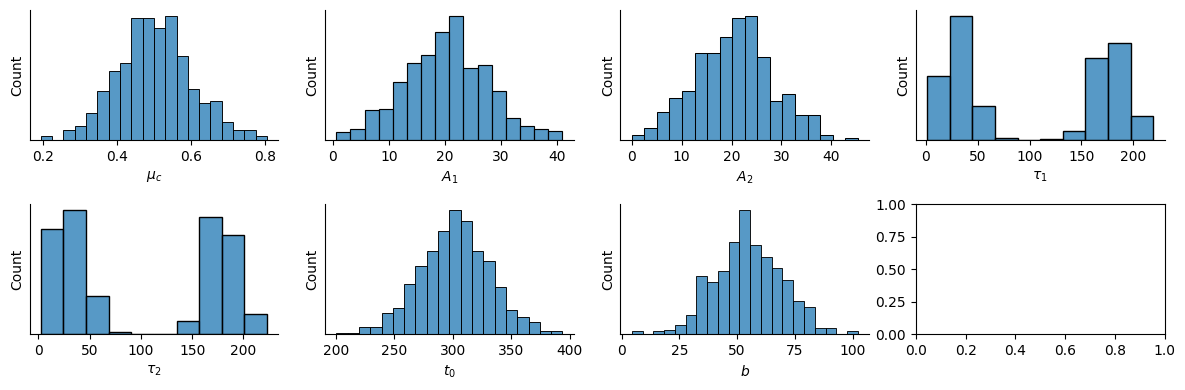

In [165]:
params = ["mu_muc", "mu_A1", "mu_A2", "mu_tau1", "mu_tau2", "mu_t0", "mu_b"]
params_names = [
    r"$\mu_c$", r"$A_1$", r"$A_2$", r"$\tau_1$", r"$\tau_2$", 
    r"$t_0$", r"$b$"
]
example_sim = simulator_hierarchical.sample(500)
f, axarr = plt.subplots(2, 4, figsize=(12, 4))
for i in range(len(params)): 
    ax = axarr.flat[i]
    sns.histplot(example_sim[params[i]].flatten(), alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_xlabel(params_names[i])
    ax.set_yticks([])
f.tight_layout()

ER: 0.94


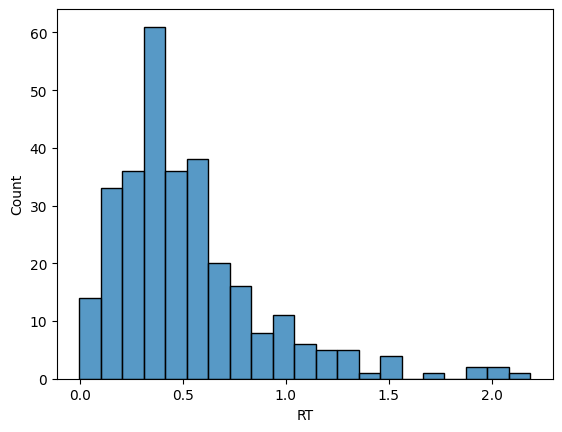

In [166]:
n = 300
example_sim = simulator_hierarchical.sample(n)
f = sns.histplot(example_sim['sim_data'][:,1])
f.set_xlabel("RT")

print("ER:", sum(example_sim['sim_data'][:,0]) / n)        # ER

In [167]:
N_TRAINING_BATCHES = 128#256
BATCH_SIZE = 32#64
EPOCHS = 5#1_000
N_LOCAL_SUBJECTS = 5  # number of subjects in a single training batch

N_TRIALS = 40         # trials per subject
N_SUBJECTS = 10#10_000   # number of subjects in one experiment
N_TEST = 100          # number of test data sets
N_SAMPLES = 100       # posterior samples per test dataset

In [168]:
param_names_global = list(global_prior.keys())

# Global (group-level) workflow
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(param_names_global, into="inference_variables")
#    .concatenate("conditions", into="context_variables")
    .rename("sim_data", "summary_variables")
)

workflow_global = bf.CompositionalWorkflow(
    adapter=adapter,
    simulator=simulator_hierarchical,
    summary_network=bf.networks.DeepSet(
        summary_dim=24             # 4 * dim of inference variables (4 * 1 * 8)
    ),
    inference_network=bf.networks.DiffusionModel(),
    checkpoint_filepath = Path(os.getcwd()).resolve(),  # save in cwd
    checkpoint_name = "TEST_HIERARCHICAL"                 # file name
)


# Local (subject-level) workflow
param_names_local = ['t0', 'muc', 'b', 'A1', 'A2', 'tau1', 'tau2']
adapter_local = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(param_names_local, into="inference_variables")
    .concatenate(param_names_global, into="inference_conditions")
    .rename("sim_data", "summary_variables")
)

workflow_local = bf.BasicWorkflow(
    adapter=adapter_local,
    summary_network=bf.networks.SetTransformer(
        summary_dim=24             # 4 * dim of inference variables (4 * 1 * 8)
    ),
    inference_network=bf.networks.StableConsistencyModel(
        dropout=0.01070354852467715
    )
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model("/local/home/lisa/Documents/uni/master/masterarbeit/dualDMC/bayesflow/TEST_HIERARCHICAL.keras")


In [169]:
processed_draws = adapter(simdata)
print(processed_draws["summary_variables"].shape)
print(processed_draws["inference_variables"].shape)

(32, 2)
(32, 14)


In [170]:
# The SetTransformer treats all 5 * N_TRIALS (choice, RT) pairs from all 
# subjects as a single unordered set.
training_data = simulator_hierarchical.sample_parallel(
    (N_TRAINING_BATCHES * BATCH_SIZE),
    n_subjects=N_LOCAL_SUBJECTS, n_trials=N_TRIALS
)
training_data['sim_data'] = training_data['sim_data'].reshape(
    (N_TRAINING_BATCHES * BATCH_SIZE, N_LOCAL_SUBJECTS * N_TRIALS, 2)
)

history = workflow_global.fit_offline(
    training_data,
    epochs=3,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'to

Epoch 1/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 44s 346ms/step - loss: 2.5218
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 44s 347ms/step - loss: 2.0926
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 352ms/step - loss: 2.4700


INFO:bayesflow:Training completed in 2.24 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at '/local/home/lisa/Documents/uni/master/masterarbeit/dualDMC/bayesflow/TEST_HIERARCHICAL.keras'.
To load it, use approximator = keras.saving.load_model("/local/home/lisa/Documents/uni/master/masterarbeit/dualDMC/bayesflow/TEST_HIERARCHICAL.keras").


In [171]:
# The SetTransformer treats all N_TRIALS (choice, RT) pairs as a single unordered set.
training_data = simulator_hierarchical.sample_parallel(
    (N_TRAINING_BATCHES * BATCH_SIZE),
    n_trials=N_TRIALS
)

history = workflow_local.fit_offline(
    training_data,
    epochs=3,
    batch_size=BATCH_SIZE,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 47s 369ms/step - loss: -1.1734
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 52s 395ms/step - loss: -2.0994
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - loss: -2.3645


INFO:bayesflow:Training completed in 2.13 minutes.


In [143]:
test_data_single = simulator_hierarchical.sample_parallel(
    N_TEST, n_subjects=N_LOCAL_SUBJECTS, n_trials=N_TRIALS
)
test_data_single['sim_data'] = test_data_single['sim_data'].reshape((
    N_TEST, N_LOCAL_SUBJECTS * N_TRIALS, 2)
)

test_posterior = workflow_global.sample(
    num_samples=N_SAMPLES,
    conditions={'sim_data': test_data_single['sim_data']},
    batch_size=BATCH_SIZE,
)

Summarizing:   0%|          | 0/4 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/4 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 1.14 minutes.


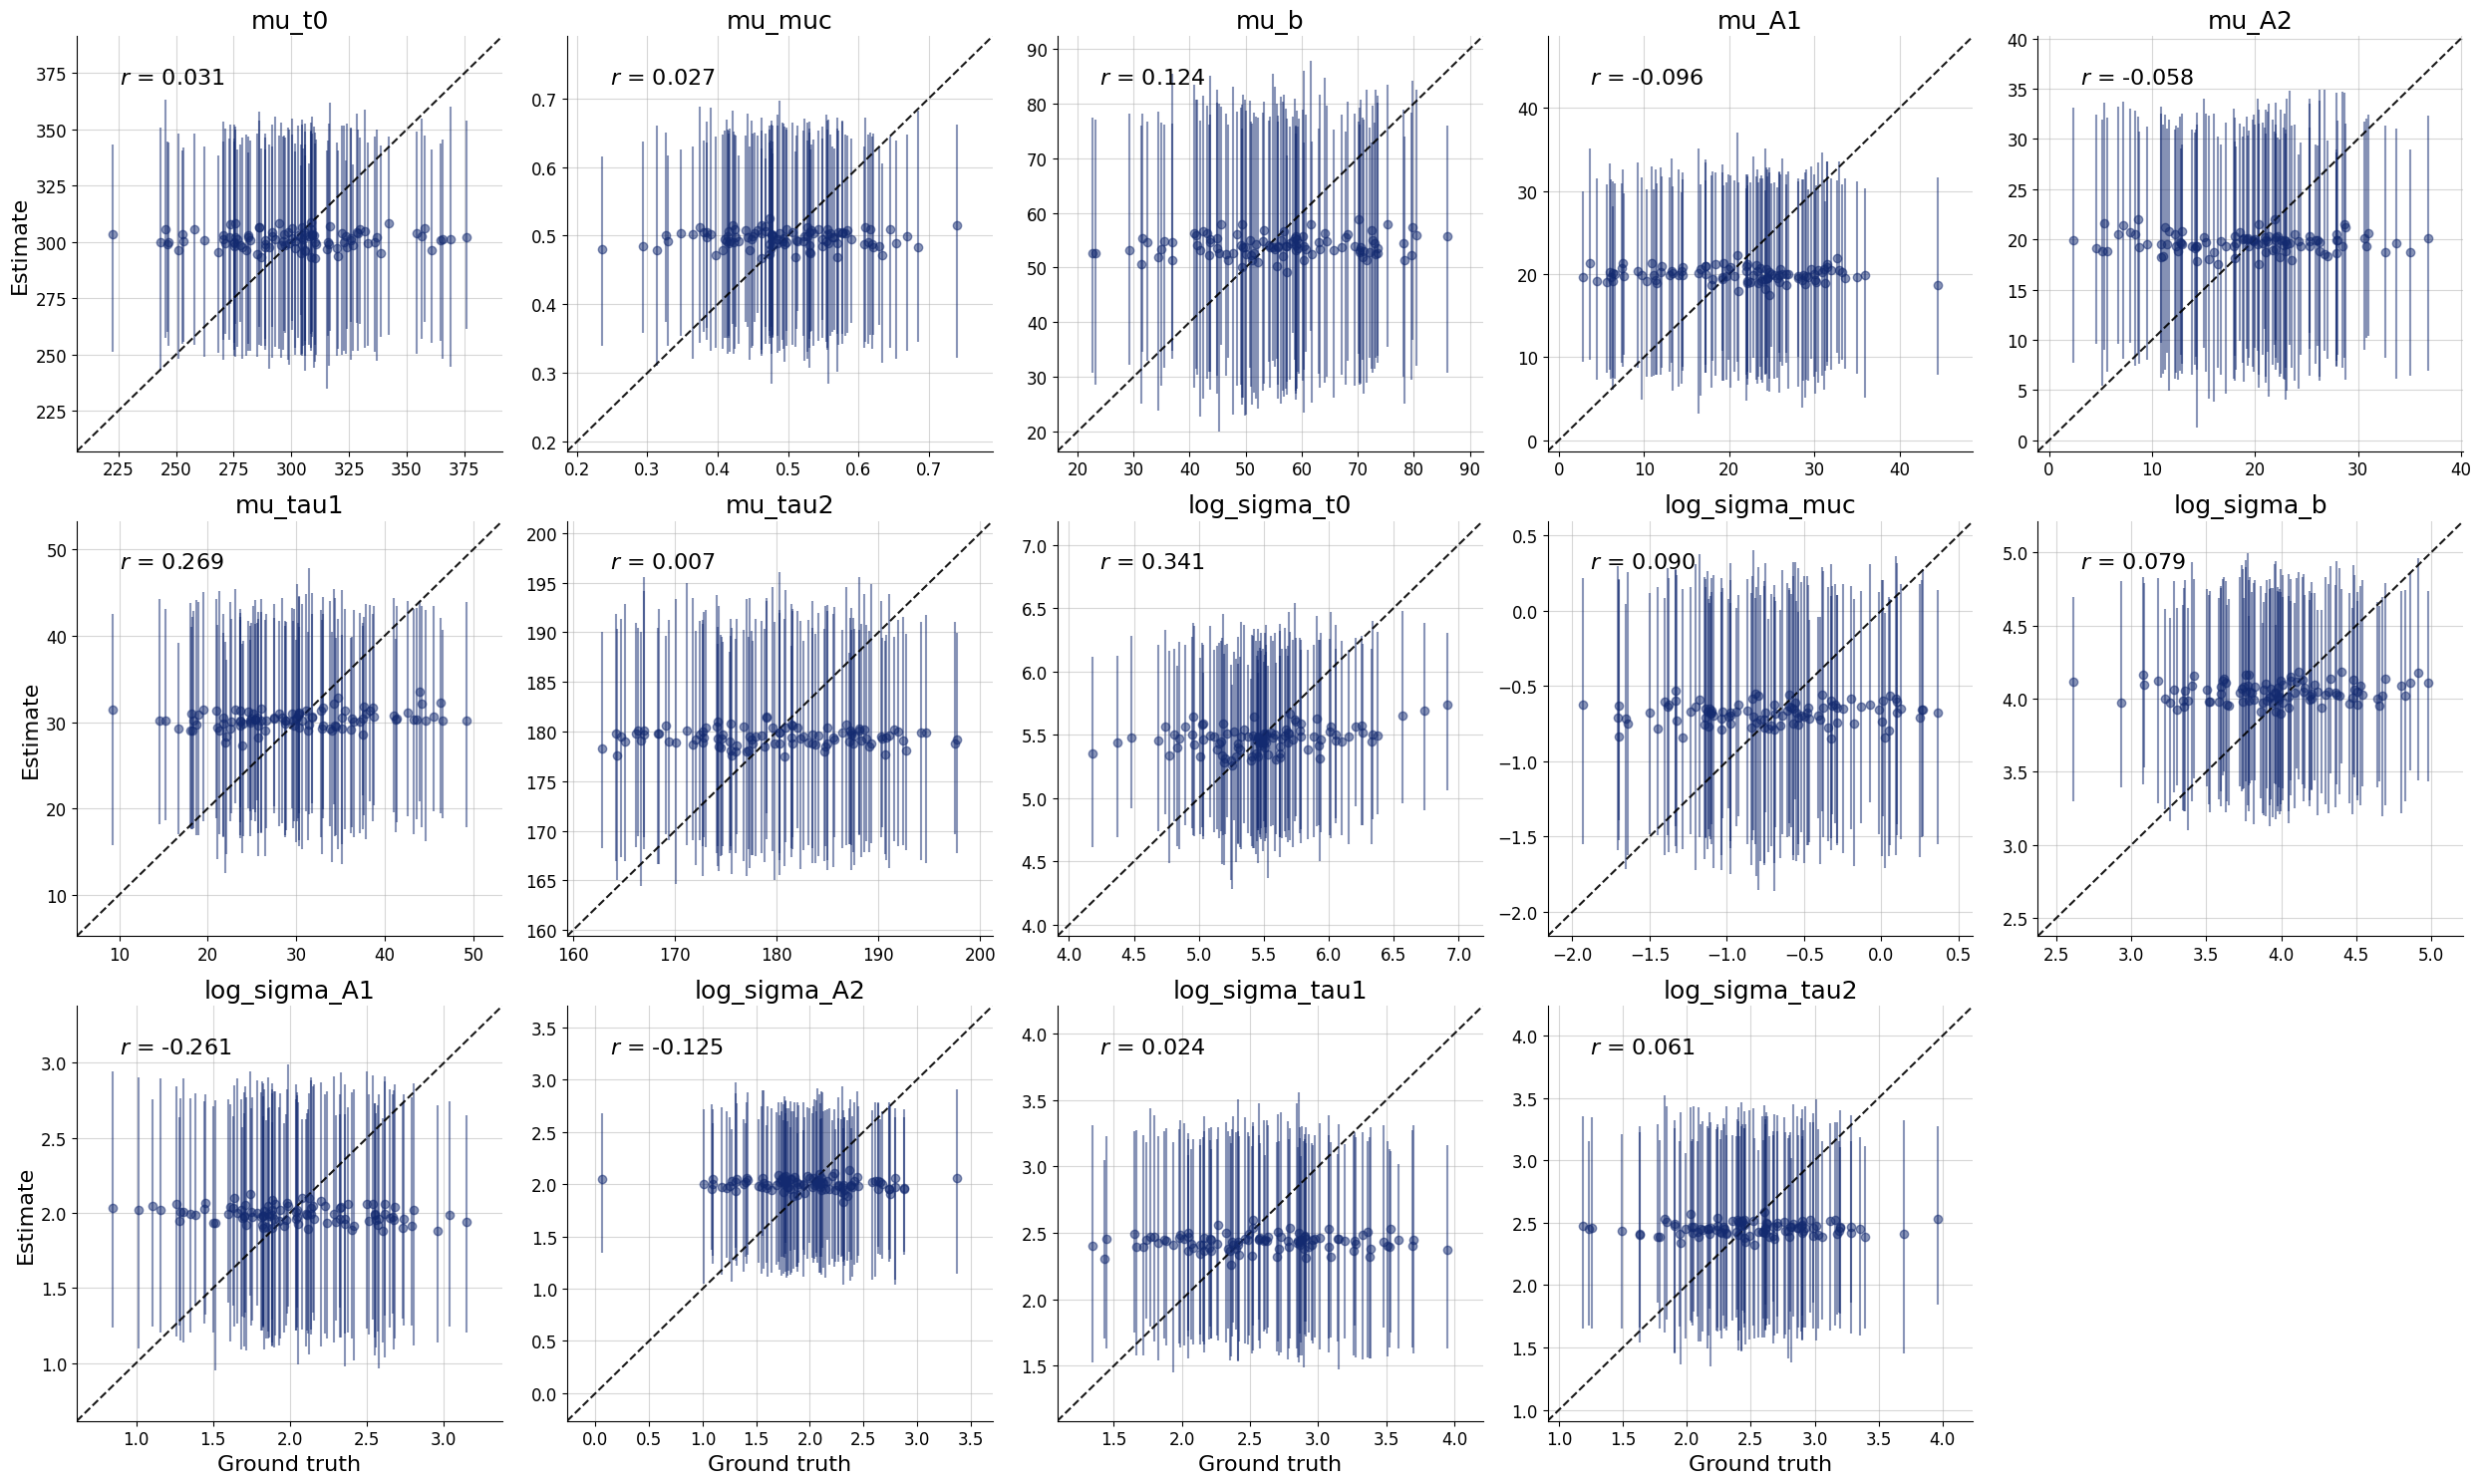

In [172]:
fig = bf.diagnostics.recovery(
    estimates=test_posterior,
    targets=test_data_single
)

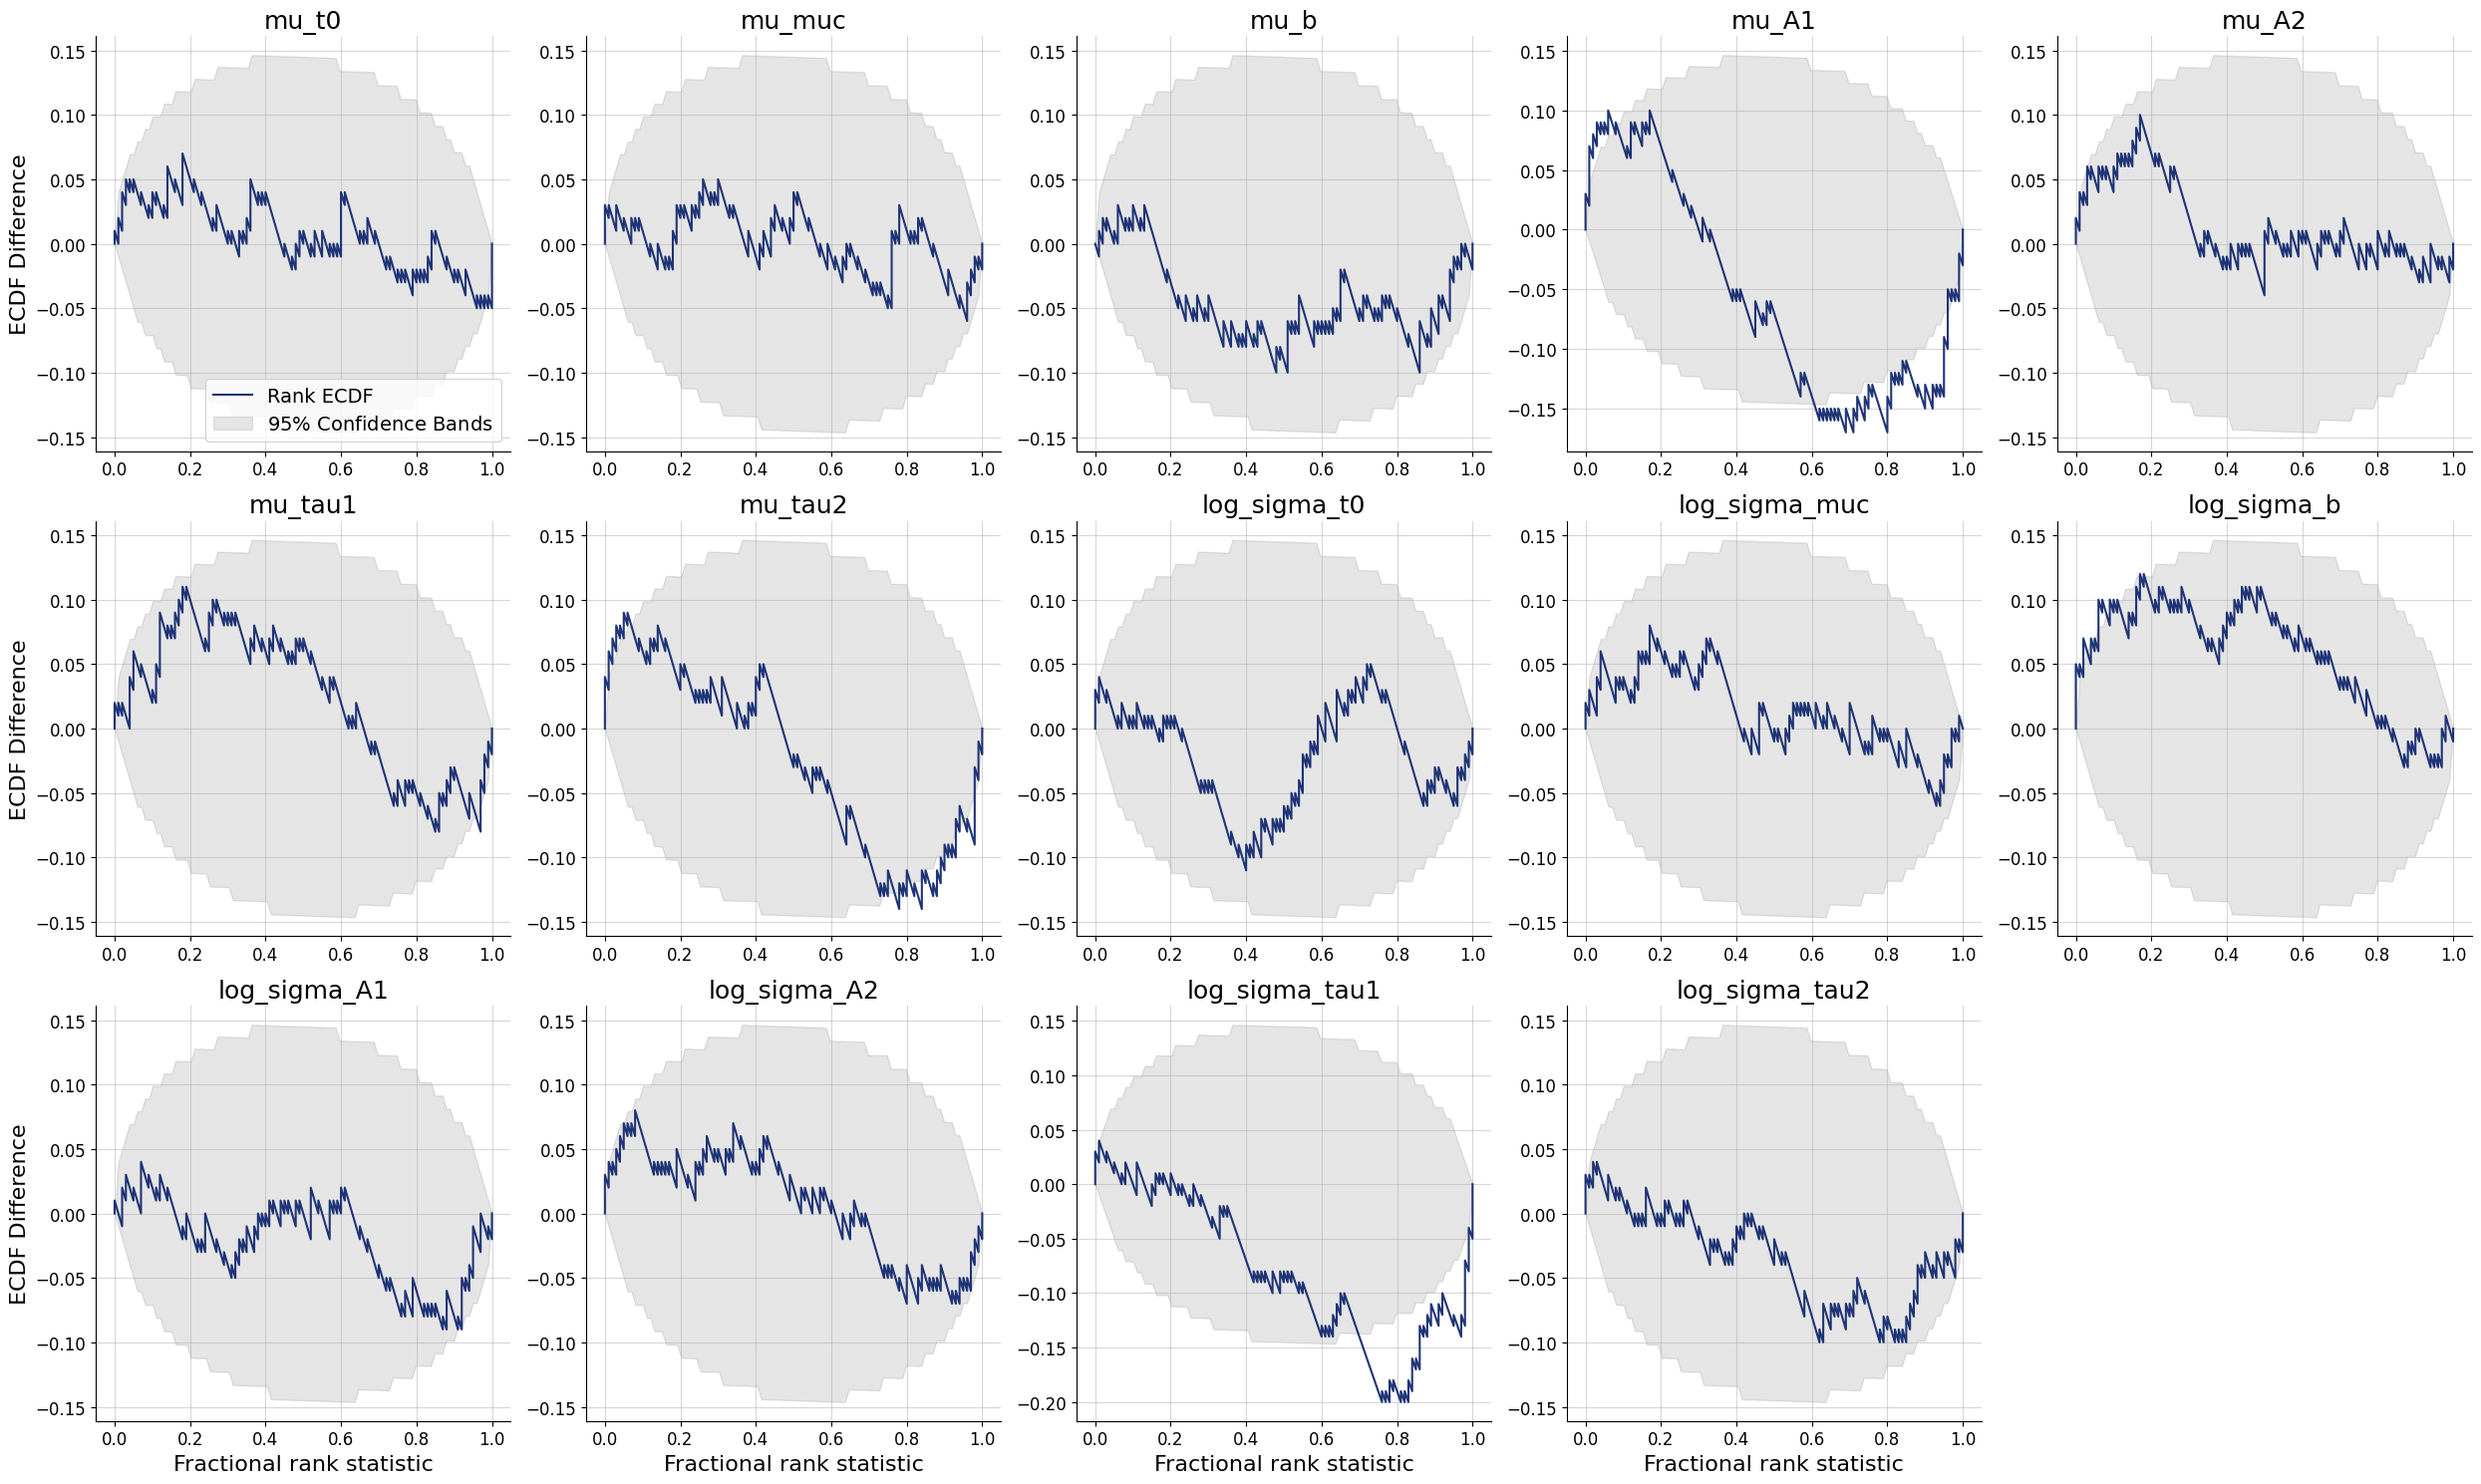

In [173]:
fig = bf.diagnostics.calibration_ecdf(
    estimates=test_posterior,
    targets=test_data_single
)

In [174]:
test_data = simulator_hierarchical.sample_parallel(
    N_TEST, n_subjects=N_SUBJECTS, n_trials=N_TRIALS
)
# bring the data in the right format
test_data['sim_data'] = test_data['sim_data'].reshape((
    N_TEST, N_SUBJECTS // N_LOCAL_SUBJECTS, N_TRIALS * N_LOCAL_SUBJECTS, 2)
)
summaries = None  # will be computed later by the workflow

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
INFO:bayesflow:Using backend 'to

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.45 minutes.


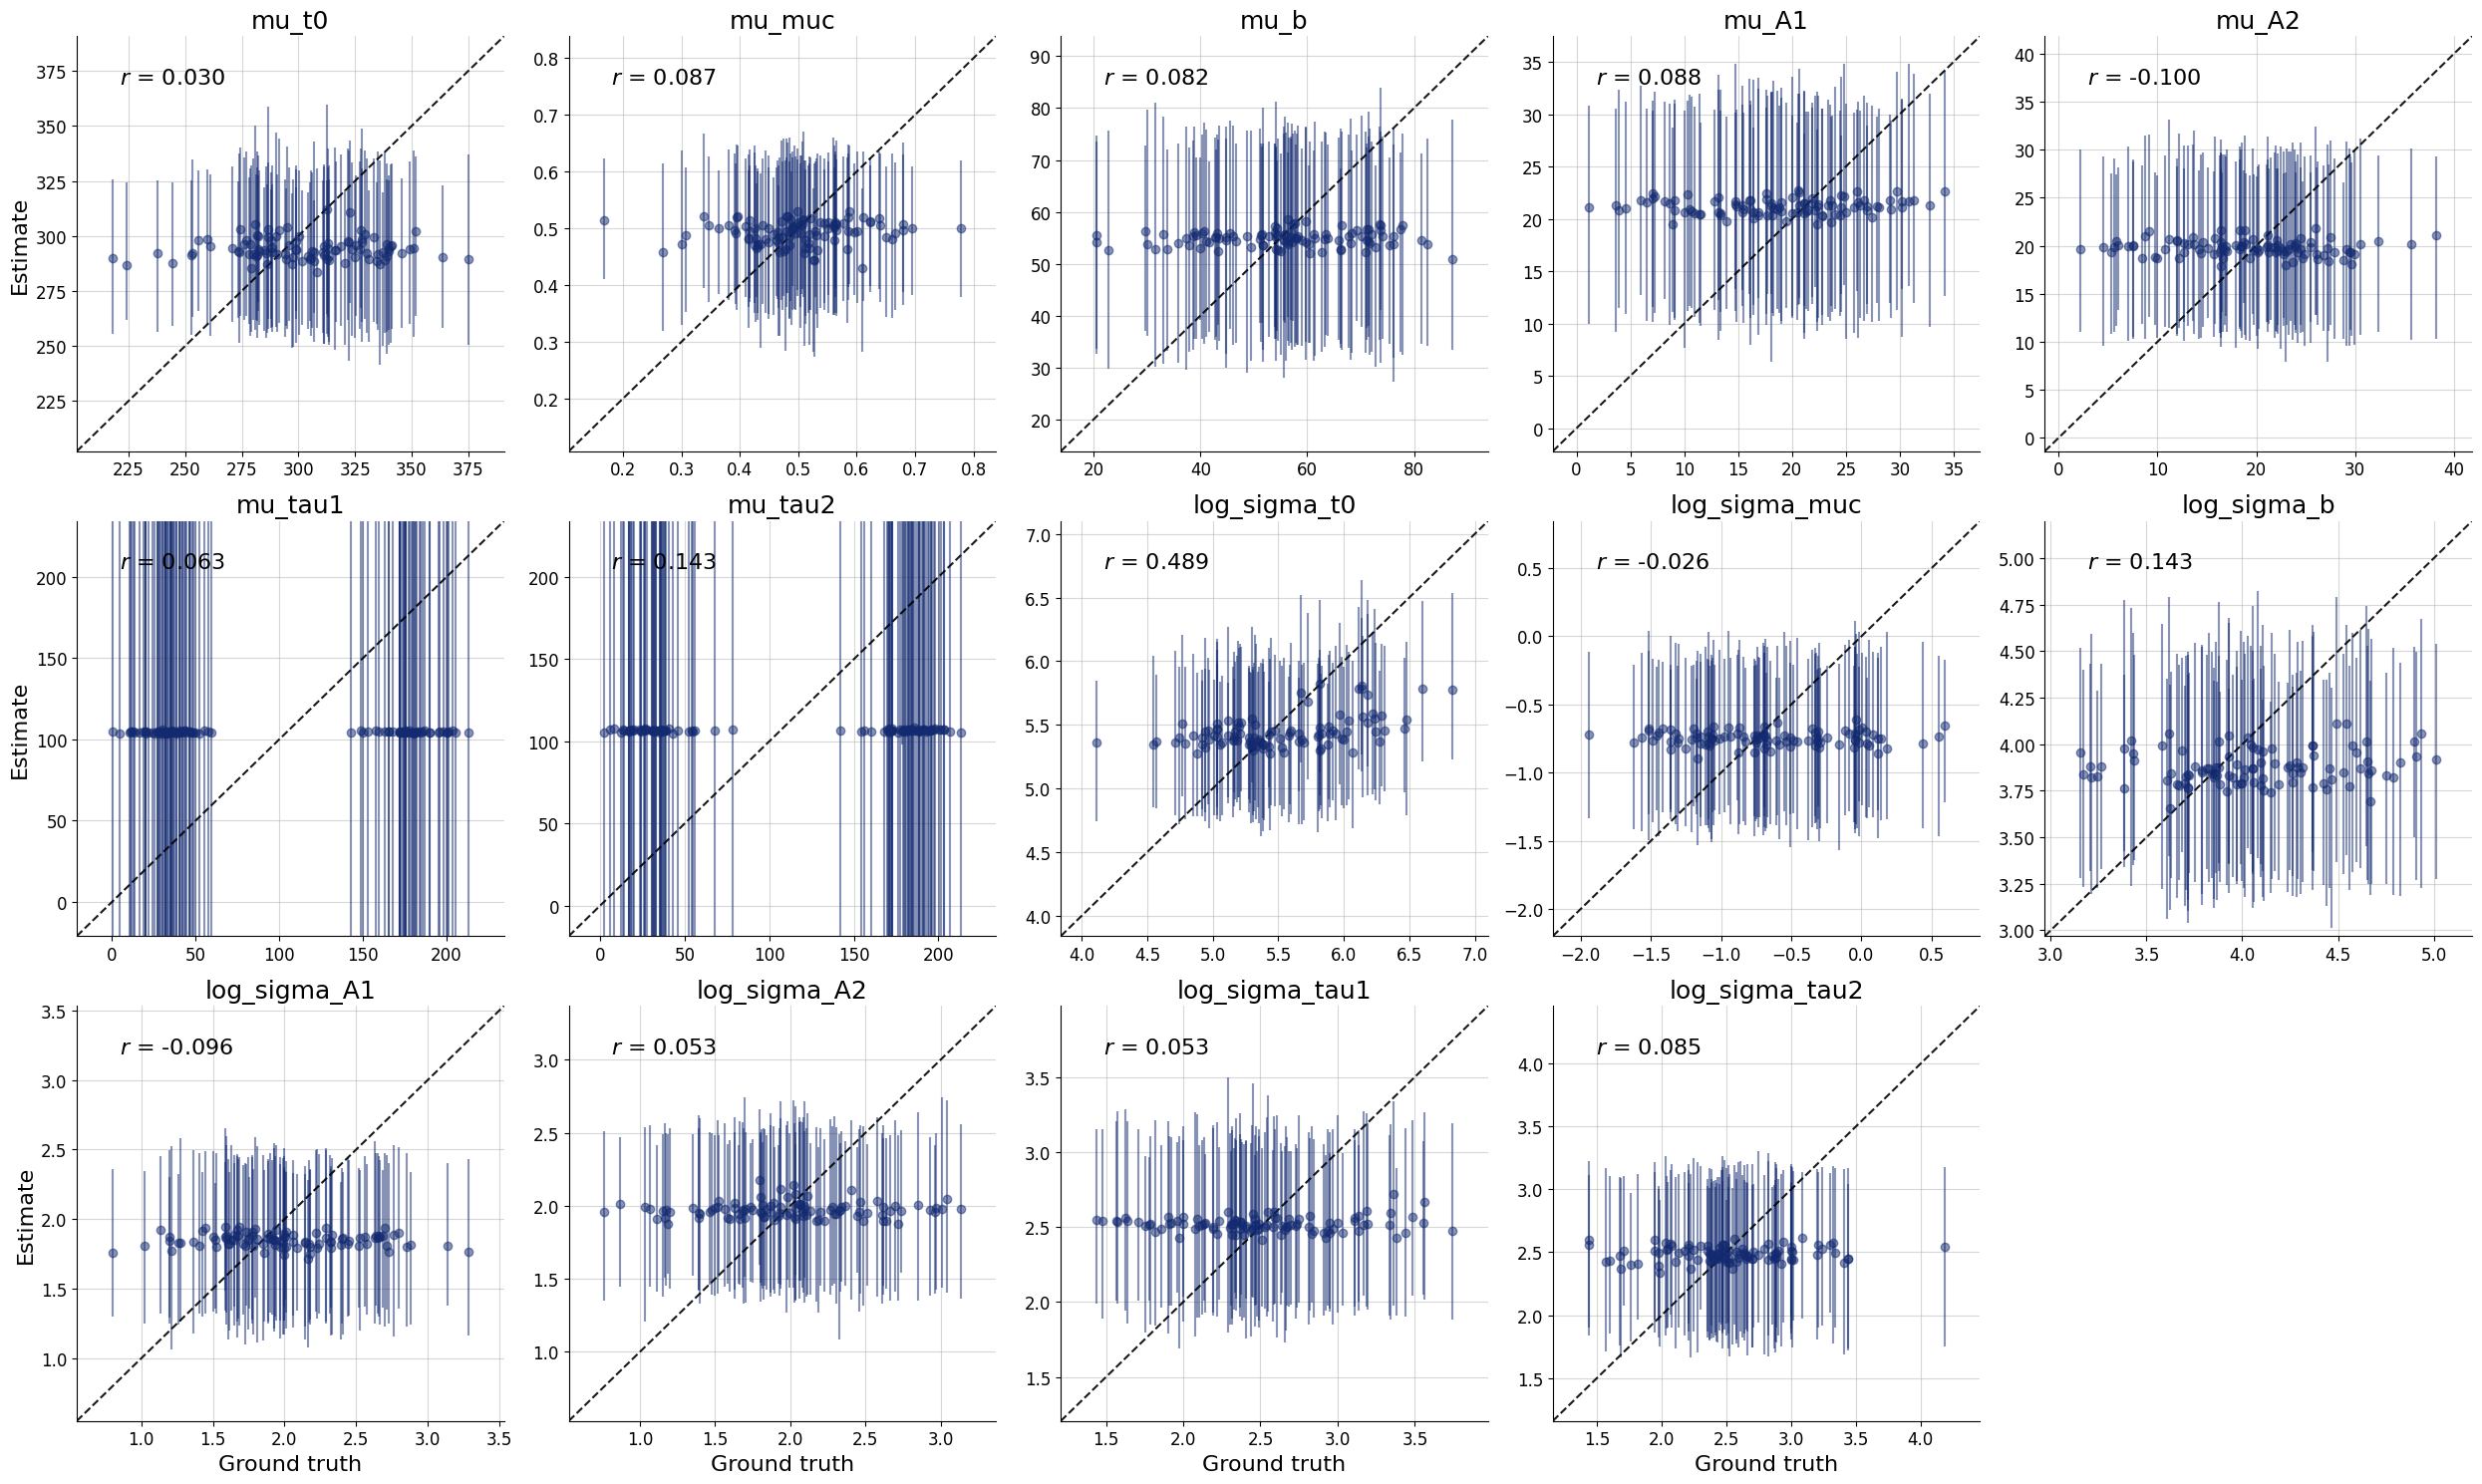

In [175]:
global_posterior = workflow_global.compositional_sample(
    num_samples=N_SAMPLES,
    conditions={'sim_data': test_data['sim_data']}, # get rid of all unnecessary keys
    compute_prior_score=prior_global_score,
    #compositional_bridge_d1=0.1,     # hyperparameter, control error accumulation
    #compositional_bridge_d0=0.1,     # hyperparameter, control error accumulation
    method='two_step_adaptive',       # hyperparameter, try "euler_maruyama" for non-adaptive method
    steps='adaptive',                 # hyperparameter, speed vs accuracy/stability
    mini_batch_size=10,               # hyperparameter, memory/speed vs accuracy
    batch_size=BATCH_SIZE*10,
    return_summaries=True,
    summaries=summaries,
)
summaries = global_posterior.pop("_summaries")  # when rerunning with different sampler hyperparameters, pass these summaries back in to avoid recomputing them

fig = bf.diagnostics.recovery(
    estimates=global_posterior,
    targets=test_data
)
plt.show()

In [177]:
# only check for N_LOCAL_CONDITIONS local conditions per dataset here
N_LOCAL_CONDITIONS = 10
smaller_test_data = {k: v[:, :N_LOCAL_CONDITIONS] for k, v in test_data.items() if k in param_names_local}
smaller_test_data['sim_data'] = test_data['sim_data'].reshape(N_TEST, N_SUBJECTS, N_TRIALS, 2)[:, :N_LOCAL_CONDITIONS]

local_posterior = workflow_local.ancestral_sample(
    conditions={'sim_data': smaller_test_data['sim_data']},
    ancestral_conditions=global_posterior,
    batch_size=BATCH_SIZE*N_SAMPLES,
)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/32 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 46.39 seconds.


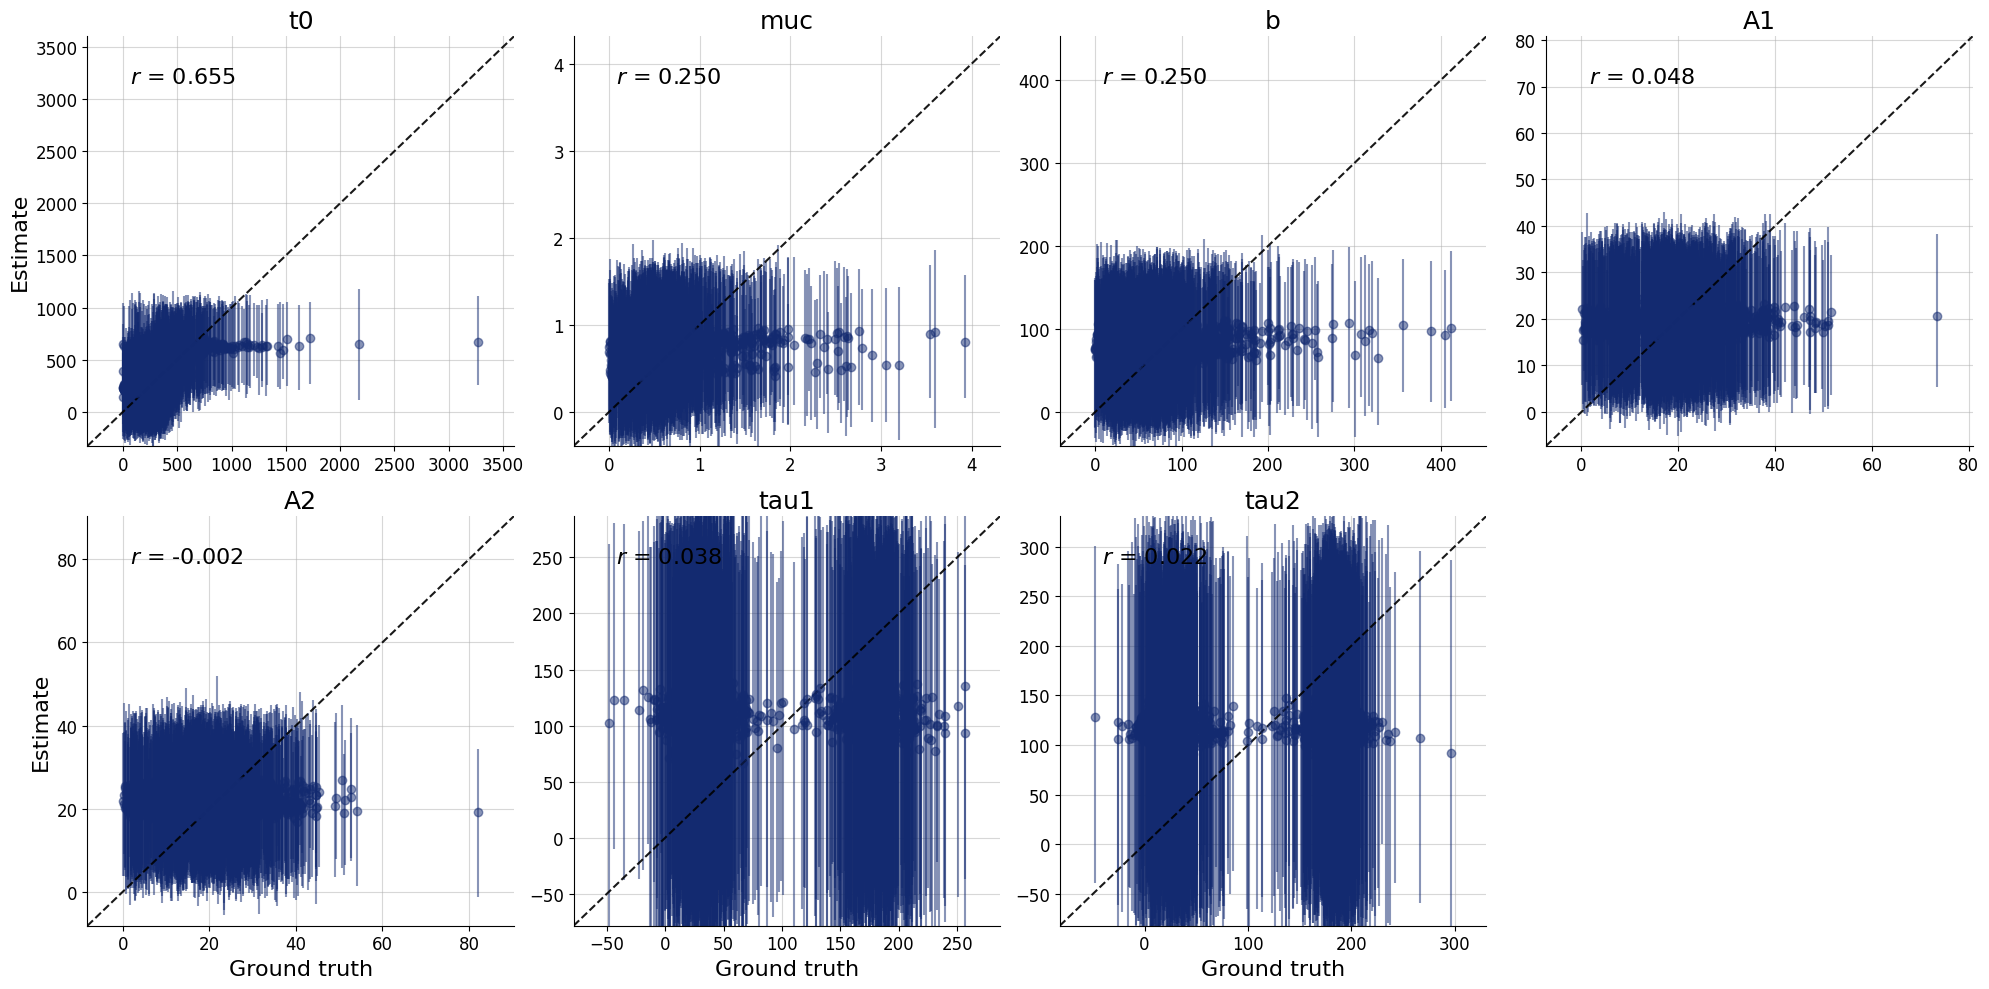

In [178]:
flat_local_posterior = {k: v.reshape(N_TEST*N_LOCAL_CONDITIONS, N_SAMPLES, 1) for k, v in local_posterior.items()}
flat_test_data = {k: v.reshape(N_TEST*N_LOCAL_CONDITIONS, 1) for k, v in smaller_test_data.items() if not k == 'sim_data'}

fig = bf.diagnostics.recovery(
    estimates=flat_local_posterior,
    targets=flat_test_data
)